5.92
3.8000000000000007


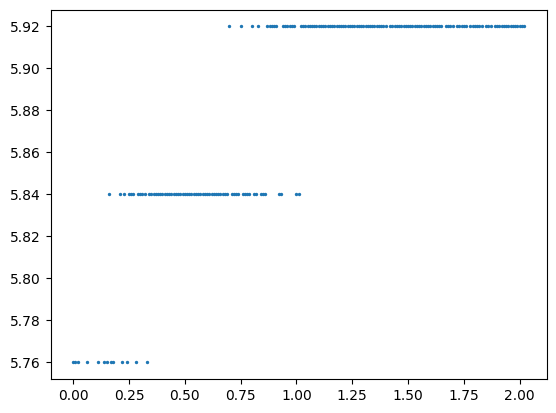

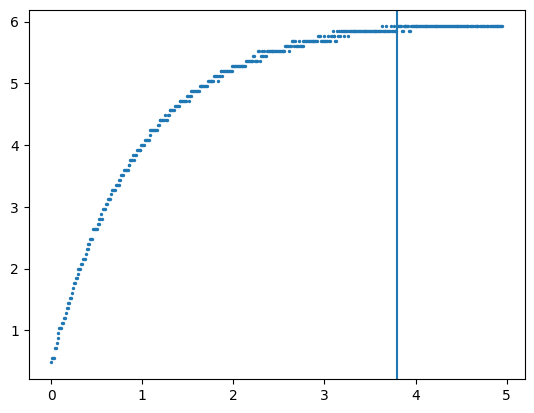

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


### Carga los datos desde el csv ###
path= ".\\cuadrada06.CSV"
dataCSV = pd.read_csv(path, delimiter=',', skiprows=16, usecols=range(1)).replace('Null', np.nan).dropna()


### Datos de configuración del osciloscopio###
dataCSV_config = pd.read_csv(path, delimiter=',',nrows=15 ,usecols=range(2))
colNames = dataCSV_config.columns.tolist()
dataCSV_config = dataCSV_config.rename(columns={colNames[0]:'DATO', colNames[1]:'VALOR'})

vscale = float(dataCSV_config.loc[dataCSV_config['DATO'] == 'Vertical Scale', 'VALOR'].values[0])
sampling = float(dataCSV_config.loc[dataCSV_config['DATO'] == 'Sampling Period', 'VALOR'].values[0])
offset = float(dataCSV_config.loc[dataCSV_config['DATO'] == 'Vertical Position', 'VALOR'].values[0])

# print(vscale)
# print(sampling)
# print(offset)
# display(dataCSV_config)


### Guarda los datos en numpy para operarlos ###
data = dataCSV.to_numpy(dtype=int).reshape(-1)


### Escala los datos dada la config del osciloscopio y crea la escala temporal ###
data = ((data/25) + offset) * vscale

t = np.arange(len(data)) * sampling

# mask = (data > -0.16) & (data < 5.19)			# Para carga y descarga DC
mask = (data > 0.4) & (data < 6) & (t<11.2) & (t>5)			# Para carga 0-6 
# mask = (data > 0.4) & (data < 6) & (t<20) & (t>16.2)			# Para carga 0-6 
mask1 = (data > 5.7) & (data < 6) & (t<11.2) & (t>5)			# Para carga 0-6 
tmask = t[mask]
tmask1 = t[mask1]

sort = np.argsort(data[mask])
d = np.searchsorted(data[mask], np.max(data[mask]), sorter=sort)
print(data[mask][d])
print(tmask[d]-tmask[0])

### Grafica ###
plt.scatter(tmask1-tmask1[0], data[mask1], s=2)
plt.show()

plt.scatter(tmask-tmask[0], data[mask], s=2)
plt.axvline(tmask[d]-tmask[0])
plt.show()

,Vmax,sigma_Vmax,Vinf,sigma_Vinf,tau,sigma_tau
0,5.9862,0.003,0.4893,0.0073,0.9847,0.0027


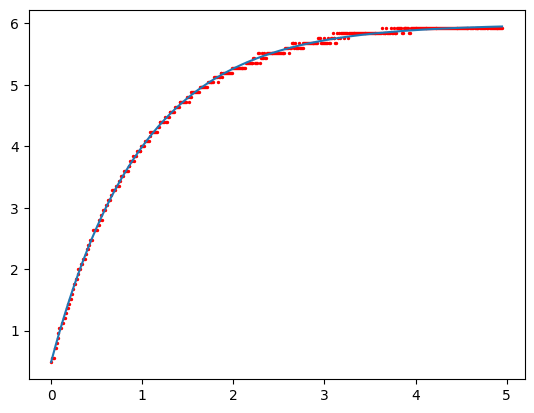

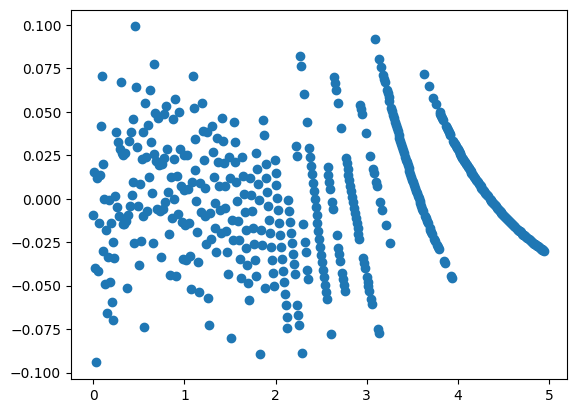

In [54]:
from scipy.optimize import curve_fit

def model(t,Vinf, Vmax, tau):
	return Vmax + (Vinf-Vmax) * np.exp(-t/tau)

p0 = [data[0], data[-1], 1.0]
popt, pcov = curve_fit(model, tmask-tmask[0], data[mask], p0=p0)

uncertainty = np.sqrt(np.diag(pcov))

df_valTeo = pd.DataFrame({'Vmax':[np.around(popt[1],4)],'sigma_Vmax':[np.around(uncertainty[1],4)], 'Vinf':[np.around(popt[0],4)],'sigma_Vinf':[np.around(uncertainty[0],4)], 'tau':[np.around(popt[2],4)],'sigma_tau':[np.around(uncertainty[2],4)]})

# print(popt)
display(df_valTeo)

plt.plot(tmask-tmask[0],model(tmask-tmask[0],*popt))
plt.scatter(tmask-tmask[0],data[mask], c='red', s=2)
plt.show()
plt.scatter(tmask-tmask[0],data[mask]-model(tmask-tmask[0], *popt))
plt.show()

In [247]:
0.9933*5.9862
# Vinf + (Vmax-Vinf) * np.exp(-t/tau)

-popt[2] * np.log((popt[1] - 5.94609246) / (popt[1] - popt[0]))


np.float64(4.845879706470706)

In [269]:
7/25

0.28